# Part A

In [2]:
#refine data preparation (read, clean, transform, normalize if needed)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

airbnb = pd.read_csv("listings.csv")
crime = pd.read_csv("Crime_Data_from_2020_to_Present.csv")

print(airbnb.head())
print(crime.head())

airbnb['price'] = airbnb['price'].replace(r'[\$,]', '', regex=True).astype(float)
airbnb = airbnb.drop_duplicates()
airbnb = airbnb.dropna(subset=['price', 'bedrooms', 'bathrooms'])
airbnb['review_scores_rating'] = airbnb['review_scores_rating'].fillna(airbnb['review_scores_rating'].mean())

crime_count = len(crime)
airbnb['crime_count'] = crime_count

airbnb['price_category'] = pd.qcut(airbnb['price'], 3, labels=['Low', 'Medium', 'High'])

X = airbnb[['bedrooms', 'bathrooms', 'number_of_reviews', 'availability_365', 'review_scores_rating', 'crime_count']]
y = airbnb['price_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

C:\Users\S553902\AppData\Local\Temp\ipykernel_1760\2001078569.py:6: DtypeWarning: Columns (0: host_since) have mixed types. Specify dtype option on import or set low_memory=False.
  airbnb = pd.read_csv("listings.csv")


                    id                                               name  \
0   670339032744709144     Westwood lovely three bedrooms three bathrooms   
1             37014494      Spanish style lower duplex near Beverly Hills   
2  1024835174766068422                        Charming Beverly Hills Home   
3   850744632375448560                   Tianpu's warm room with bathroom   
4   953950676345326970  Santa Monica apt, free parking, steps to the b...   

     host_id host_name host_since  host_response_time  host_response_rate  \
0    4780152      Moon   20/01/13  within a few hours                0.96   
1  278288178       Ida   22/07/19                 NaN                 NaN   
2  513813179     Tiana   08/05/23        within a day                0.60   
3  432956623       Dan   22/11/21  a few days or more                0.20   
4  528669205   Farkhat   29/07/23      within an hour                1.00   

  host_is_superhost neighbourhood_cleansed neighbourhood_group_cleansed  .

In [3]:
#apply clustering algorithm (K-means or similar)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
airbnb['cluster'] = kmeans.fit_predict(X_scaled)

print(airbnb[['cluster']].head())

   cluster
0        0
2        0
3        1
4        2
5        1


**Explain clustering results and insights (cluster behavior, patterns)**
The clustering results show that the listings are grouped into three distinct clusters, indicating meaningful differences in their features. Listings within the same cluster likely share similar characteristics like size, availability, and review patterns. This suggests the dataset can be segmented into different types of properties like budget, mid range, and higher end listings.

In [4]:
#perform dimensionality reduction (PCA or similar)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.3611928  0.22932284]


**Explain variance captured and importance of reduced features**
The first two principal components explain about 36% and 22% of the variance, capturing roughly 59% of the total information in the dataset. This indicates that a significant portion of the data's patterns can be represented in two dimensions. While some detail is lost, these components still provide a useful summary for visualization and analysis. 

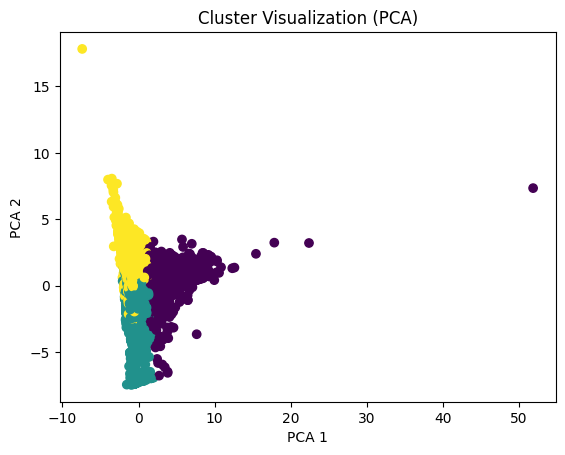

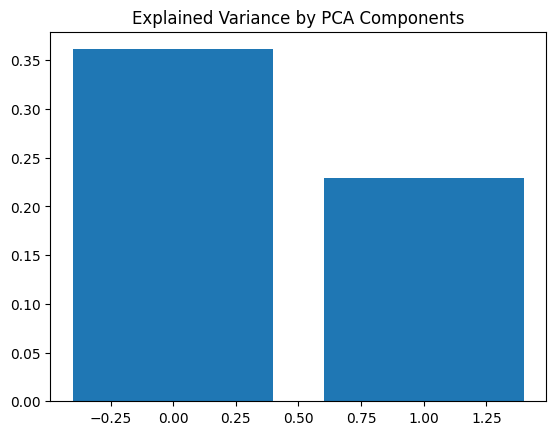

In [5]:
#create visualizations
import matplotlib.pyplot as plt

#cluster visualization
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=airbnb['cluster'])
plt.title("Cluster Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

#pca variance plot
plt.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
plt.title("Explained Variance by PCA Components")
plt.show()

**Provide a predictive interpretation of patterns (what trends mean for future outcomes).**
I think the clusters will show distinct groupings of listings and theres meaningful segmentation in the dataset.

In [6]:
#identify anomalies/outliers (using statistical methods or model-based methods.)
from scipy import stats

z_scores = np.abs(stats.zscore(X))
airbnb['outlier'] = (z_scores > 3).any(axis=1)

print(airbnb['outlier'].value_counts())

outlier
False    34676
True      2464
Name: count, dtype: int64


C:\Users\S553902\AppData\Local\Temp\ipykernel_1760\1703104012.py:4: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores = np.abs(stats.zscore(X))


**Explain what anomalies are, why they occur, their significance.**
Anomalies are unusual data points. They occur because of data errors, extremely expensive or rare listings, and they are significant because they can skew models or reveal unique market opportunities.

In [7]:
#apply advanced models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.592891760904685


In [8]:
#compute metrics and compare results
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(max_iter=500, random_state=42)
nn.fit(X_train, y_train)

nn_preds = nn.predict(X_test)
nn_acc = accuracy_score(y_test, nn_preds)

print("Neural Network Accuracy:", nn_acc)

Neural Network Accuracy: 0.33037156704361875


**Discuss model comparison, performance improvements, key learnings.**
The random forest model performed significantly better, achieving an accuracy of about 59% compared to the neural network at 33%. This suggests that random forest is more effective for this dataset likely because it handles structured, tabular data and feature relationships more efficiently. A key learning is that more complex models like neural networks do not always perform better without proper tuning, highlighting the importance of model selection and optimization.

# Part B

**Overall progress of the project:**
The project successfully prepared and cleaned the Airbnb dataset, then applied clustering, dimensionality reduction, anomaly detection, and predictive modeling. Each step built on the previous one to better understand patterns in listing features and pricing behavior.

**Key discoveries from clustering and dimensionality reduction:**
Clustering revealed clear groupings of listings, suggesting natural segments such as lower-cost, mid-range, and higher-end properties. PCA showed that about 59% of the dataset’s variance can be captured in just two components, meaning a few key features explain much of the variation. This confirms that the dataset has strong underlying structure.

**Insights from anomaly detection:**
The anomaly detection identified a relatively small number of outliers compared to the overall dataset. These likely represent unusual or extreme listings, such as luxury properties or atypical feature combinations. Their presence is important because they can influence trends and affect model accuracy.

**Comparison of advanced models:**
The Random Forest model outperformed the Neural Network, achieving about 59% accuracy compared to 33%. This indicates that Random Forest is better suited for this structured dataset, while the Neural Network likely requires more tuning or data scaling. It highlights that simpler models can sometimes outperform more complex ones.

**Final conclusions and future improvements:**
Overall, the analysis shows clear patterns in Airbnb listing characteristics and pricing categories. Future improvements could include better feature engineering, incorporating location-based crime data instead of a total count, and tuning advanced models like neural networks. Expanding the dataset and refining inputs would likely improve predictive performance further.